# Additional analysis — LA-TAM / NR4A mechanism (RCC myeloid niche)

Follow-up on the CellRank/celloracle myeloid trajectory (Mono1 → terminal TAM/mDC/osteoclast).
Goal: test whether **NR4A2/NR4A3** regulate the LA-TAM program, what **upstream niche signals**
activate them, and which **pathways/TFs** are active along the TAM trajectory. All results are
hypothesis-generating. Full narrative + claim mapping: `outputs/SUMMARY.md`.

**Object:** `Cleaned_Data/myeloid_FINAL_labels.h5ad` (16,881 myeloid cells; RCC bone-met + benign BM).
TAM is tumor-restricted (2534/2548 TAM cells in the Tumor faction).

> Tasks were executed by the scripts in `analysis/` on SLURM; this notebook just loads the results
> from `outputs/`. It does **not** modify any pre-existing file.


In [ ]:
import pandas as pd, os
from IPython.display import Image, display, Markdown
pd.set_option('display.width',180); pd.set_option('display.max_columns',30)
ROOT='/autofs/projects-t3/hussain/scProj/kidney-cancer/additional_analysis'; T=f'{ROOT}/outputs/tables'; F=f'{ROOT}/outputs/figures'
def show(p, **kw):
    return pd.read_csv(p, **kw)
def fig(name):
    display(Image(filename=f'{F}/{name}'))


## Task 1 — pySCENIC regulons + AUCell
262 regulons. **No NR4A2/NR4A3 regulon survived cisTarget motif-pruning.** NFKB1/HIF1A/NFE2L2
regulon AUCell is elevated in TAM-Tumor; NR4A→LA-TAM link unsupported even at the GRNBoost
co-expression level.


In [2]:
print('Regulon target summary (focus TFs):')
display(show(f'{T}/scenic_regulon_targets.csv'))
print('\nNR4A/NFKB regulon vs LA-TAM hypergeometric (NR4A regulons are EMPTY -> undefined):')
display(show(f'{T}/scenic_nr4a_latam_hypergeom.csv'))
print('\nGRNBoost2 co-expression (pre-pruning) NR4A/NFKB/HIF1A vs LA-TAM:')
display(show(f'{T}/scenic_grnboost_nr4a_latam_coexpr.csv'))
print('\nAUCell TAM-Tumor specificity (Mann-Whitney, TAM-Tumor vs rest):')
display(show(f'{T}/scenic_tam_tumor_specificity.csv'))


Regulon target summary (focus TFs):


,TF,n_targets,latam_targets,targets
0,NR4A2,0,NaN,NaN
1,NR4A3,0,NaN,NaN
2,NFKB1,99,NaN,ABCA9;ABL2;ACKR3;ACVR1C;ADAP1;AKT2;ANO10;ARHGA...
3,RELA,7,NaN,CDKN2B;DYSF;H6PD;RELA;RELB;SMARCAD1;XRCC1
4,HIF1A,47,NaN,ACO1;ACSL3;ALDOC;AMIGO2;ANKRD37;ATP13A3;BNIP3;...
5,NFE2L2,325,NaN,ABI1;ACSL1;ACSL3;ACSL4;ADAM17;ADIPOR1;ADIPOR2;...



NR4A/NFKB regulon vs LA-TAM hypergeometric (NR4A regulons are EMPTY -> undefined):


,TF,n_targets_in_universe,LA_TAM_universe,overlap_k,overlap_genes,expected,hypergeom_p
0,NR4A2,0,10,0,NaN,0.000000,NaN
1,NR4A3,0,10,0,NaN,0.000000,NaN
2,NFKB1,99,10,0,NaN,0.067757,1.0



GRNBoost2 co-expression (pre-pruning) NR4A/NFKB/HIF1A vs LA-TAM:


,TF,n_total_targets,top300_LATAM_overlap,LATAM_hits,hypergeom_p_top300,LATAM_target_ranks
0,NR4A2,5828,1,C1QA,0.187408,"{'C1QA': 277, 'CD9': 1413, 'APOC1': 1236, 'GPN..."
1,NR4A3,4269,0,NaN,1.000000,"{'C1QA': 872, 'CD9': 1414, 'APOC1': 1055, 'GPN..."
2,NFKB1,2595,0,NaN,1.000000,"{'GPNMB': 2478, 'C1QC': 2381, 'APOE': 2467}"
3,RELA,621,0,NaN,1.000000,{}
4,HIF1A,3523,1,GPNMB,0.187408,"{'APOC1': 954, 'GPNMB': 185, 'FABP5': 2095, 'C..."
5,NFE2L2,4105,0,NaN,1.000000,"{'C1QA': 3090, 'CD9': 2479, 'C1QC': 3647, 'C1Q..."



AUCell TAM-Tumor specificity (Mann-Whitney, TAM-Tumor vs rest):


,TF,mean_TAM_tumor,mean_rest,log2FC,mannwhitney_U,p_greater,n_tam_tumor
0,NFKB1,0.051930,0.026182,0.988017,28540538.0,0.000000,2534
1,RELA,0.005767,0.009798,-0.764631,17504332.0,0.999999,2534
2,HIF1A,0.050826,0.024661,1.043317,29135776.5,0.000000,2534
3,NFE2L2,0.070238,0.046552,0.593426,30050620.0,0.000000,2534


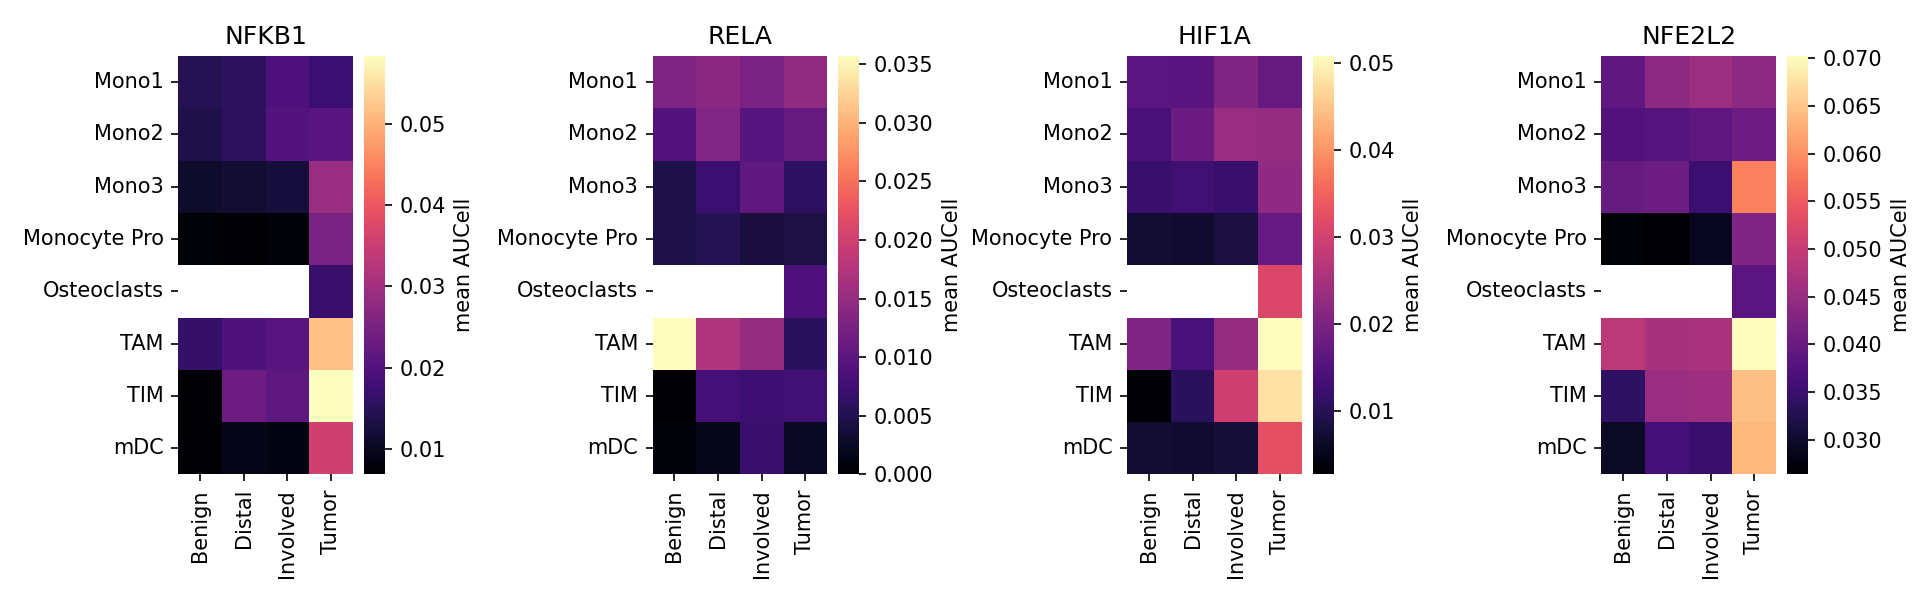

In [3]:
fig('scenic_aucell_heatmap.png')


## Task 2 — NicheNet (niche → TAM)
Top ligand driving the LA-TAM program = **TGFB1**; NR4A2's top predicted upstream ligand = **VEGFA**.


In [4]:
print('Top 15 ligands by activity (Pearson) for the LA-TAM program:')
display(show(f'{T}/nichenet_ligand_activity.csv').head(15))
print('\nTop ligands predicted to induce NR4A2:')
display(show(f'{T}/nichenet_top_ligands_for_NR4A2.csv'))


Top 15 ligands by activity (Pearson) for the LA-TAM program:


,ligand,pearson,aupr,sender_types,rank
0,TGFB1,0.239307,0.437896,Tumor;MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothel...,1
1,HLA-C,0.201454,0.408842,Tumor;MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothel...,2
2,MMP14,0.189955,0.404312,MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothelial;os...,3
3,HSPG2,0.188938,0.403158,MSC-1;MSC-2;MSC-3;Peri-2;Endothelial;osteoclasts,4
4,EDIL3,0.188311,0.394931,MSC-1;MSC-2;Peri-1;Peri-2,5
5,A2M,0.185681,0.401217,MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothelial,6
6,HLA-A,0.185042,0.400499,Tumor;MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothel...,7
7,CXCL14,0.184544,0.394648,Tumor;MSC-1;MSC-2;MSC-3,8
8,RPS19,0.183853,0.400054,Tumor;MSC-1;MSC-2;MSC-3;Peri-1;Peri-2;Endothel...,9
9,CLU,0.182918,0.401975,Tumor;MSC-1;MSC-2;MSC-3;Endothelial,10



Top ligands predicted to induce NR4A2:


,Unnamed: 0,reg_potential
0,VEGFA,0.245753
1,TGFB1,0.011092
2,IFITM1,0.009711
3,SDC2,0.008422
4,COL1A2,0.008228
5,MMP2,0.008173
6,CLU,0.008164
7,LAMA4,0.007974
8,ANXA1,0.007683
9,CFH,0.007562


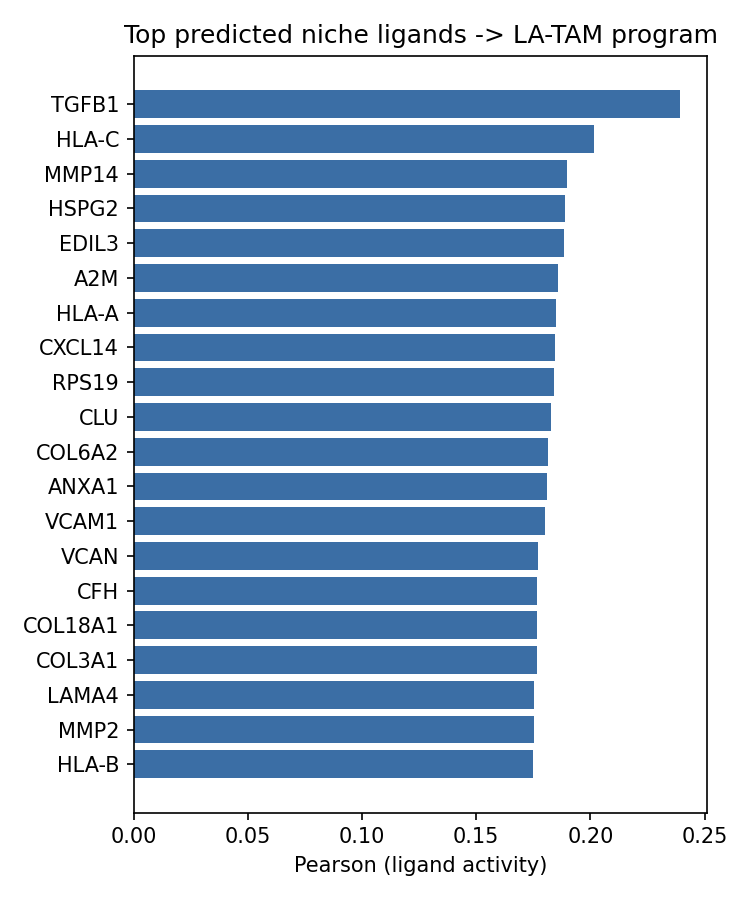

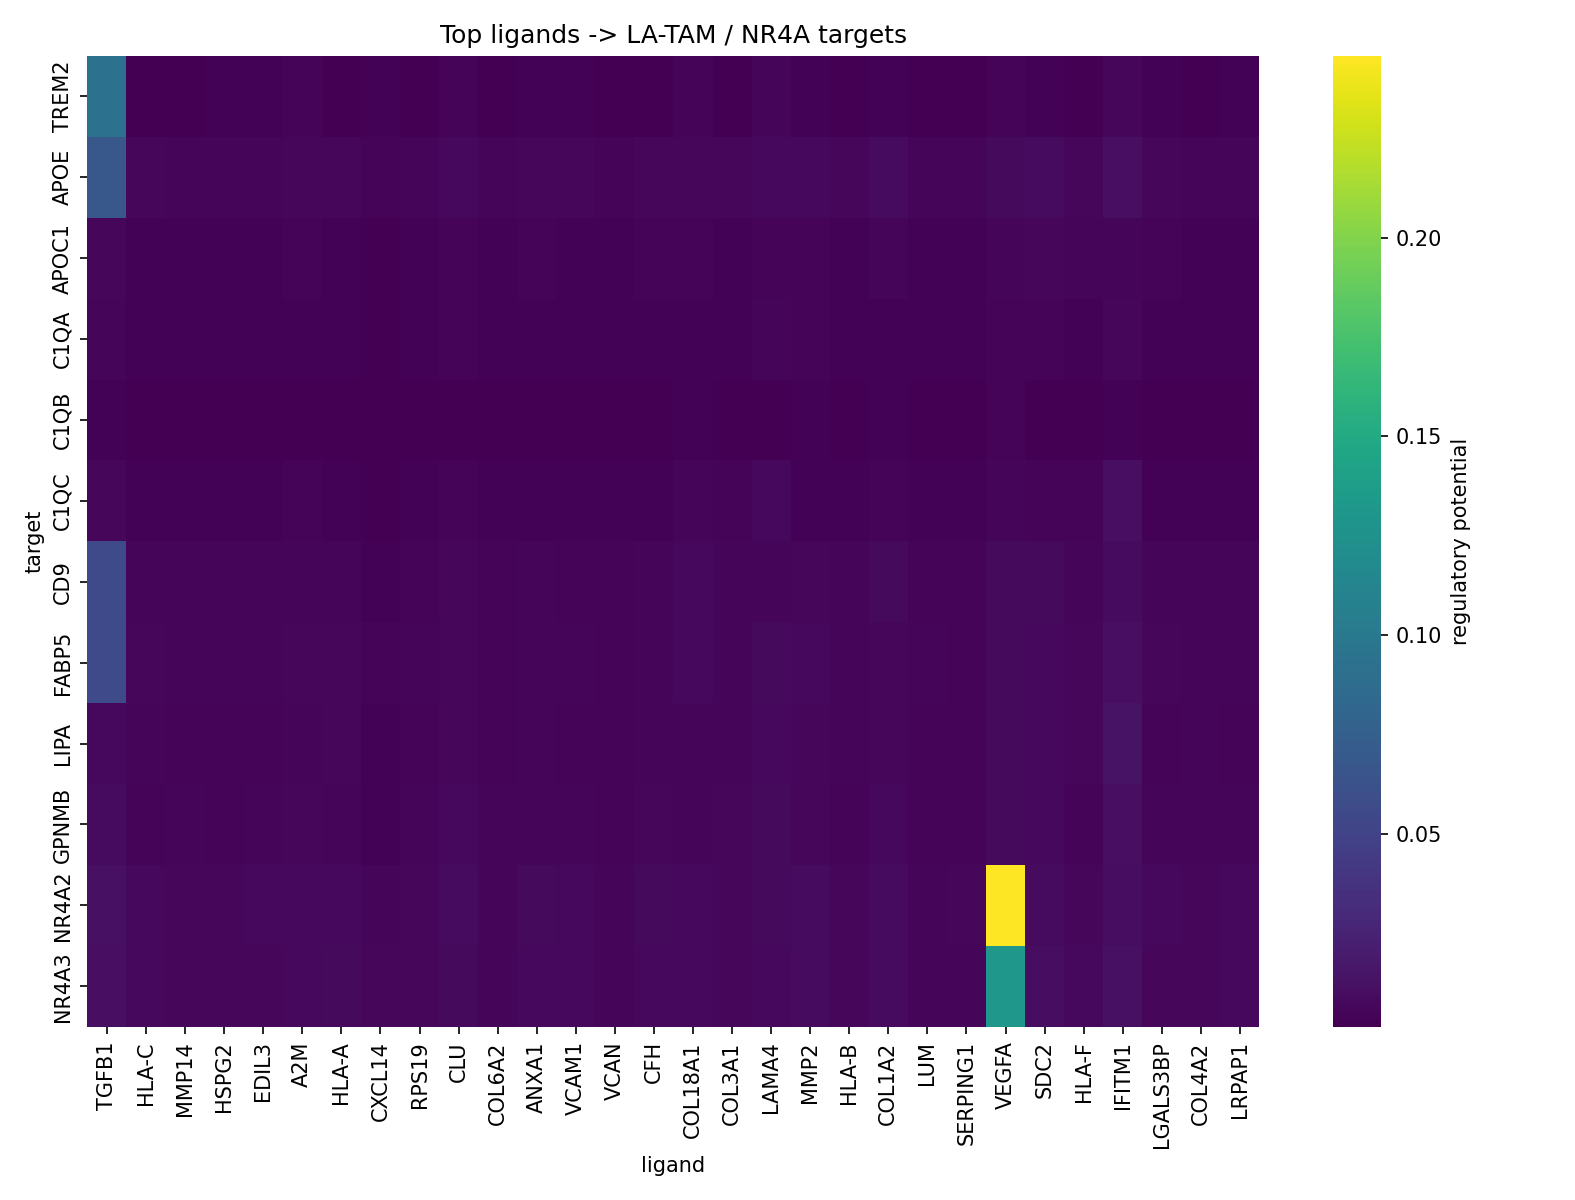

In [5]:
fig('nichenet_ligand_activity.png'); fig('nichenet_ligand_target_heatmap.png')


## Task 3 — decoupleR PROGENy (pathways) + CollecTRI (TF activity)
NF-κB & hypoxia rise strongly into the Tumor faction; NR4A2 activity elevated in tumor TAM/TIM.


In [6]:
print('CollecTRI TF activity by faction:')
display(show(f'{T}/decoupler_collectri_by_condition.csv', index_col=0)[['NR4A2','NR4A3','NFKB1','RELA','HIF1A']].round(3))
print('PROGENy pathway activity by faction:')
display(show(f'{T}/decoupler_progeny_by_condition.csv', index_col=0)[['NFkB','Hypoxia','JAK-STAT','TNFa']].round(3))


CollecTRI TF activity by faction:


,NR4A2,NR4A3,NFKB1,RELA,HIF1A
condition,,,,,
Benign,1.287,0.025,4.393,5.077,5.494
Distal,1.141,0.045,4.515,5.155,5.583
Involved,1.285,-0.149,5.018,5.529,6.327
Tumor,1.835,-0.395,7.812,8.608,7.330


PROGENy pathway activity by faction:


,NFkB,Hypoxia,JAK-STAT,TNFa
condition,,,,
Benign,-2.518,1.542,4.343,3.526
Distal,-1.990,1.697,4.301,3.595
Involved,-1.345,2.317,3.532,3.862
Tumor,1.749,2.960,5.715,3.280


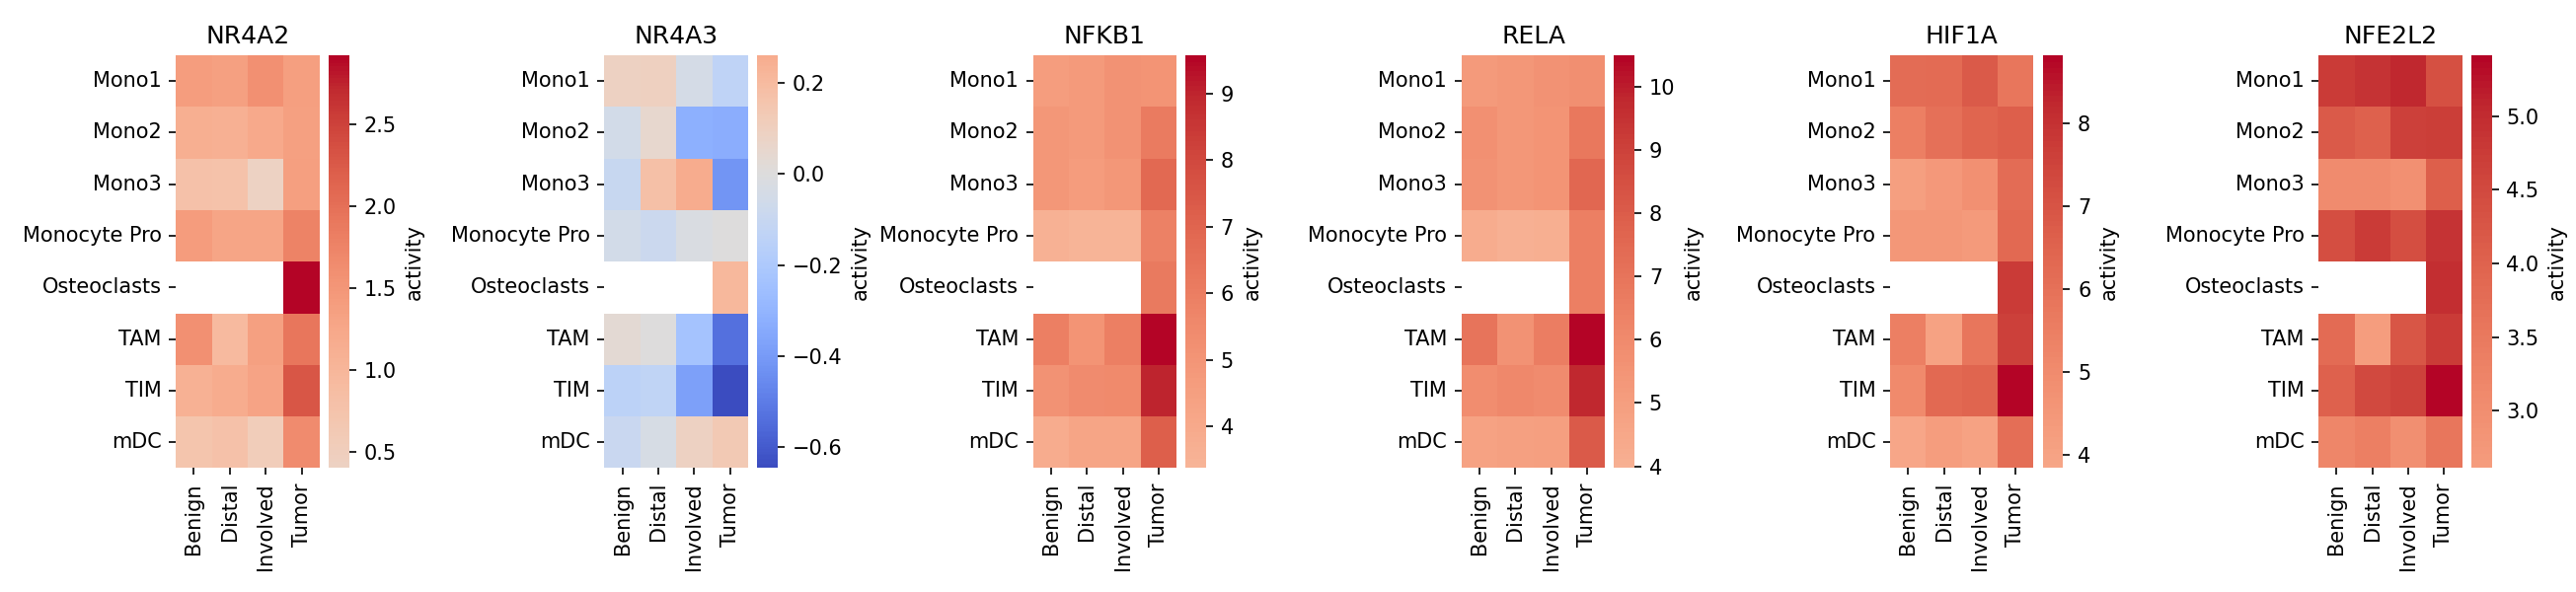

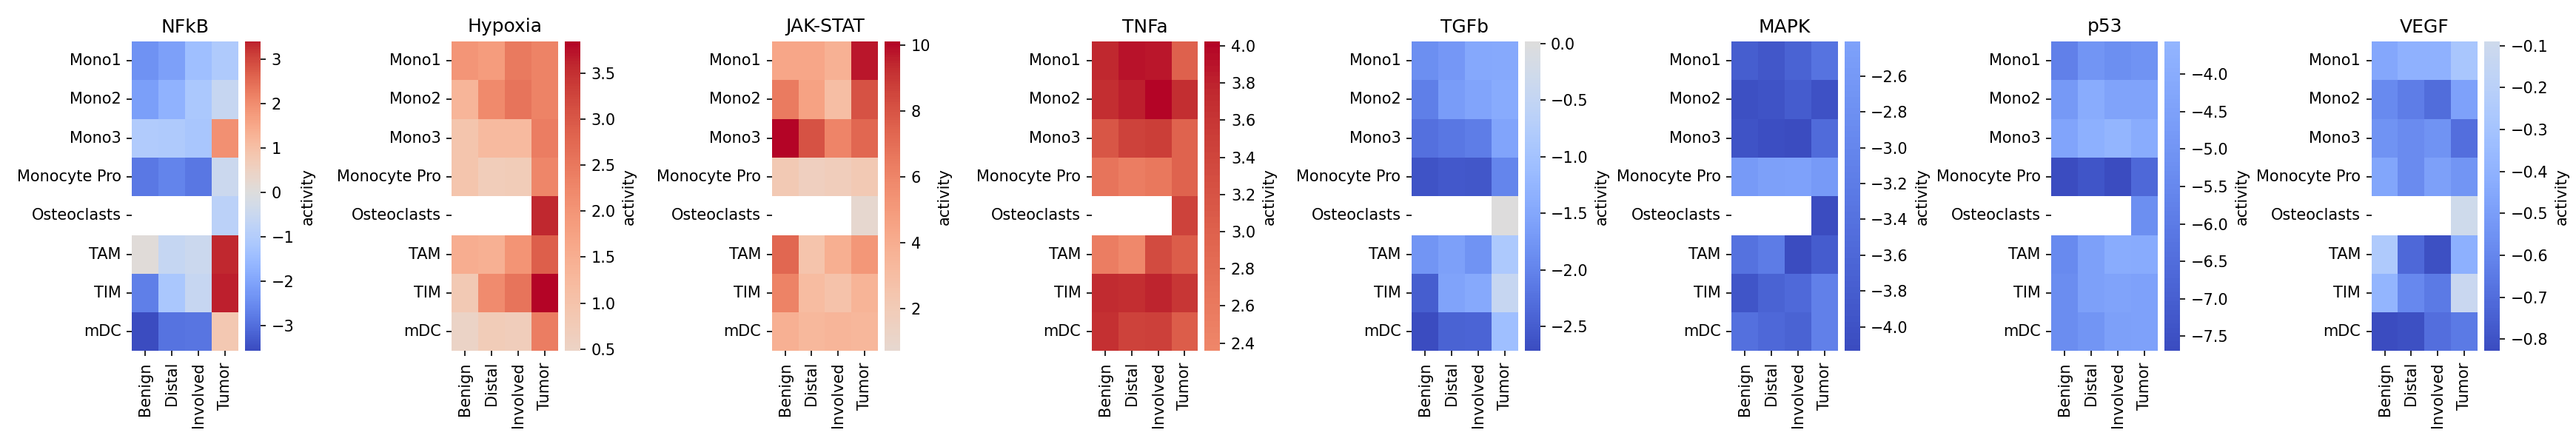

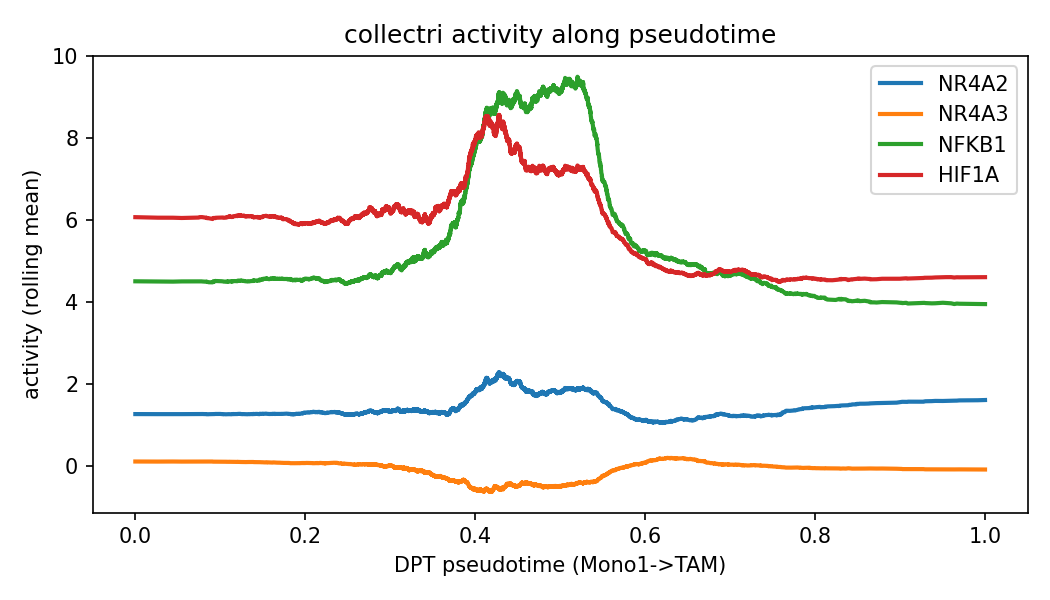

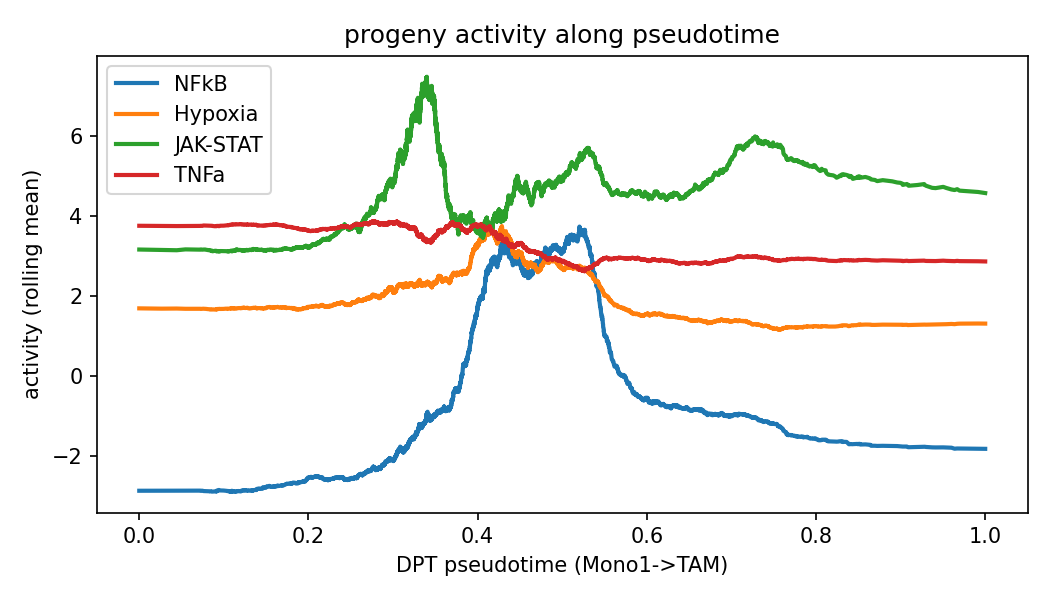

In [7]:
fig('decoupler_collectri_heatmap.png'); fig('decoupler_progeny_heatmap.png')
fig('decoupler_collectri_along_pseudotime.png'); fig('decoupler_progeny_along_pseudotime.png')


## Task 4 — pseudotime gene-trend ordering (Mono1 → TAM)
NR4A2 onset **precedes** the LA-TAM lipid genes (C1Q/APOE/CD9/GPNMB/LIPA), though peaks are
near-simultaneous — a modest, onset-level lead.


In [8]:
display(show(f'{T}/genetrend_ordering_summary.csv'))
display(show(f'{T}/genetrend_peaktimes.csv'))


,mean_NR4A_onset,mean_LATAM_onset,NR4A_precedes_LATAM,xcorr_best_lag_cells_NR4A_leads
0,0.162311,0.306422,True,0


,gene,group,onset_pt_halfmax,peak_pt
0,NR4A2,NR4A,0.000000,0.494795
1,TREM2,LA-TAM,0.000000,0.539229
2,FABP5,LA-TAM,0.000000,0.507918
3,NR4A3,NR4A,0.324622,0.492072
4,APOC1,LA-TAM,0.367326,0.509926
5,C1QA,LA-TAM,0.376713,0.499509
6,APOE,LA-TAM,0.380637,0.507558
7,CD9,LA-TAM,0.381333,0.502267
8,C1QB,LA-TAM,0.381952,0.499736
9,C1QC,LA-TAM,0.384313,0.508881


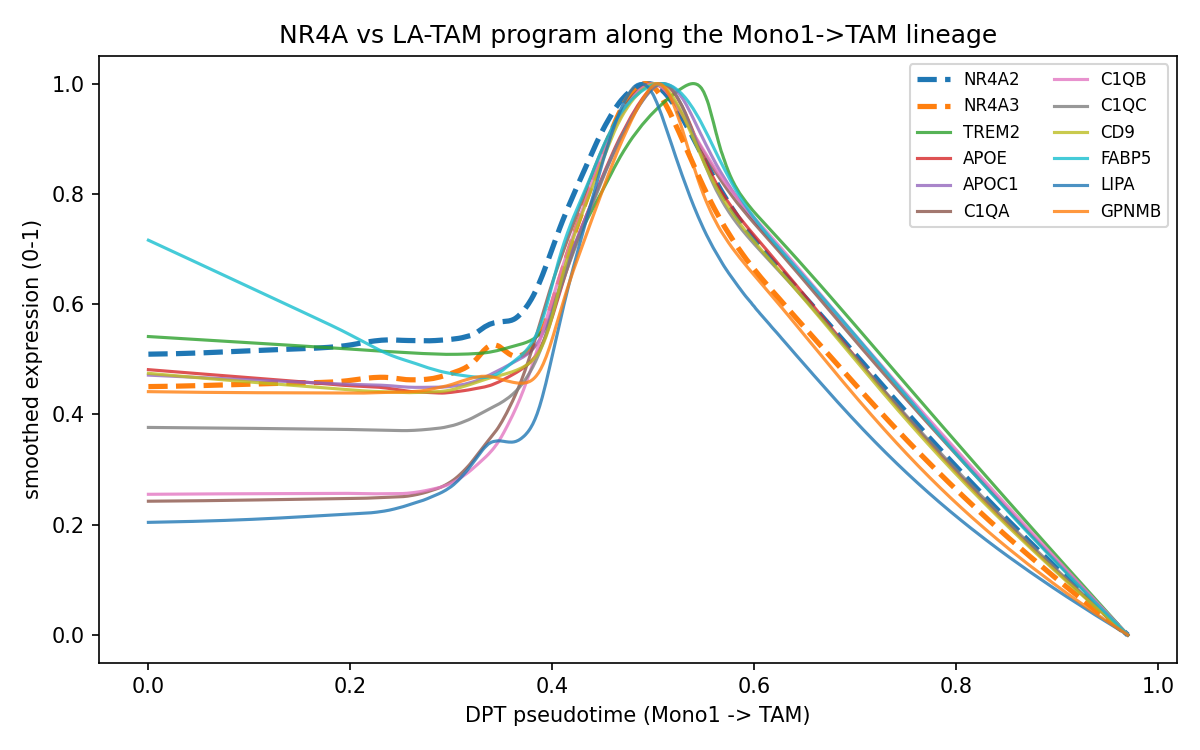

In [9]:
fig('genetrends_nr4a_vs_latam.png')


## Task 6 (optional) — TCGA-KIRC external validation (n=531)
Bulk RNA-seq is essentially **silent** on the myeloid-intrinsic NR4A↔LA-TAM link.


In [10]:
display(show(f'{T}/tcga_kirc_survival.csv'))
display(show(f'{T}/tcga_kirc_latam_nr4a2_corr.csv'))


,signature,HR_per_SD,CI_low,CI_high,p,n
0,LATAM,1.143045,0.985821,1.325345,0.076591,531
1,NR4A2,1.016498,0.877023,1.178155,0.827965,531


,spearman_rho,p,n
0,-0.041208,0.343266,531


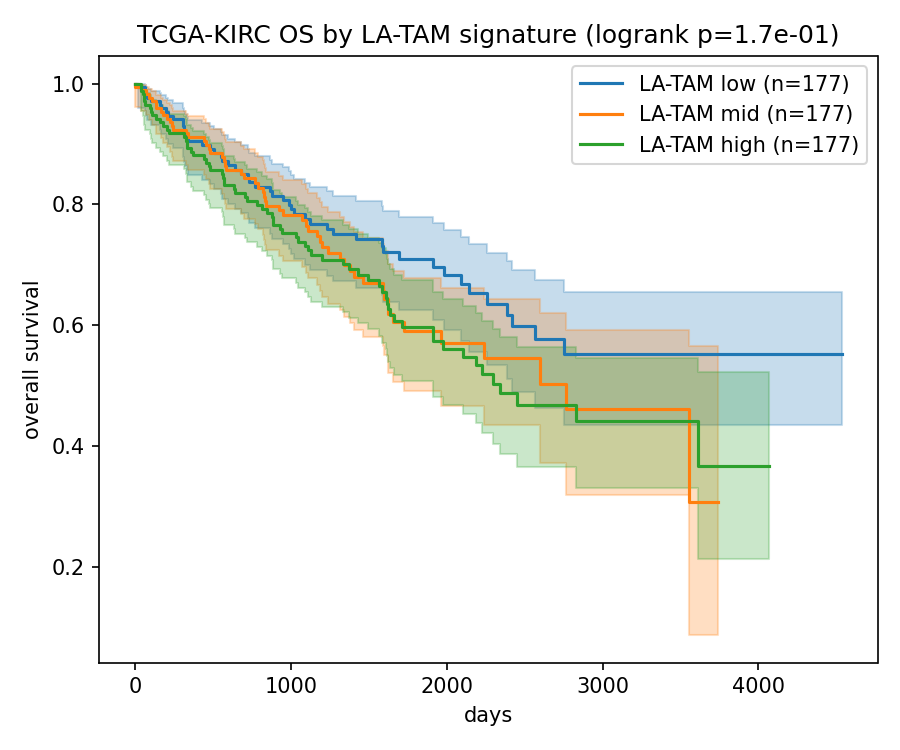

In [11]:
fig('tcga_kirc_km_latam.png')


## Summary → claims
See `outputs/SUMMARY.md` for the full mapping. In brief:
- **(a)** LA-TAM identity — **supported**.
- **(b)** NF-κB conserved regulator — **supported** (NFKB1 robust across SCENIC + decoupleR).
- **(c)** NR4A2/NR4A3 focal tumor-restricted; NFE2L2/HIF1A — **mixed**: NR4A2 is niche-induced
  (VEGFA/hypoxia), early, tumor-associated, but **not** a direct de-novo driver of the LA-TAM
  lipid module; NR4A3 largely silent; NFE2L2/HIF1A regulons elevated in TAM.
- **(d)** ATF3 (PCa) — **untestable here** (absent from this RCC object).
